In [763]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

from v2_preparation import process_modis, process_landsat_spacecraft, slice_by_dates, filter_columns, process_insitu
from v2_sensor_fusion import fuse_sensors
from v2_visualization import format_metrics_table, plot_observed_modeled_timeseries

from v2_features_processing import(
    process_spectral_data, principal_component_analysis, cross_correlations_analysis, merge_datasets,
    add_lags, add_time)
from v2_modelling_framework import(
    preprocess_for_ML_chrono, tune_model, train_model, evaluate_model, plot_pred_vs_real, apply_model, 
    plot_timeseries_results
)

In [764]:
study_site = 'SDH2'
start_date = '2000'
end_date = '2026'

if study_site == 'SDH1':
    target = 'SDH1PS01_gw-depth_m'
    insitu_filepath = '../data/processed/in-situ/SDH1_daily-insitu-data.csv'
    modis_filepath = '../data/processed/satellites/SDH1_MT_500m_2000-03_2026-06_v2.csv'
    landsat_filepath = '../data/processed/satellites/SDH1_L_30m_2000-02_2026-06.csv'

elif study_site == 'SDH2':
    target = 'SDH2PP01_gw-depth_m'
    insitu_filepath = '../data/processed/in-situ/SDH2_daily-insitu-data.csv'
    modis_filepath = '../data/processed/satellites/SDH2_MT_500m_2000-03_2026-06_v2.csv'
    landsat_filepath = '../data/processed/satellites/SDH2_L_30m_2000-02_2026-06.csv'

else:
    print(f'{study_site} not supported as study site')

band_mapping = {
    'brightness': ('brightness', 'brightness'),
    'greenness': ('greenness', 'greenness'),
    'wetness': ('wetness', 'wetness')
}

modis_cols = ['blue', 'green', 'red', 'nir', 'nir2','swir1', 'swir2']
landsat_cols = ['blue_mean', 'green_mean', 'red_mean', 'nir_mean', 'swir1_mean', 'swir2_mean']

In [765]:
landsat_df = process_landsat_spacecraft(
    filepath=landsat_filepath,
    start_date=start_date,
    end_date=end_date,
    cols_to_keep=landsat_cols,
    outlier_threshold=3.0,
    stats_min_points=10
)

modis_df = process_modis(
    filepath=modis_filepath,
    start_date=start_date,
    end_date=end_date,
    cols_to_keep=modis_cols,
    outlier_threshold=3.0,
    smooth_window=31
)

In [766]:
def compute_landsat_TCT(
        df: pd.DataFrame,
        spacecraft_col: str = 'Spacecraft',
        blue_col: str = 'blue_mean',
        green_col: str = 'green_mean',
        red_col: str = 'red_mean',
        nir_col: str = 'nir_mean',
        swir1_col: str = 'swir1_mean',
        swir2_col: str = 'swir2_mean'
) -> pd.DataFrame:
    """
    Compute Tasseled Cap Transformation (Brightness, Greenness, Wetness) for Landsat data.
    Applies Crist (1985) coefficients for TM/ETM+ (Landsat 5 and 7) and 
    Zhai et al. 5-band coefficients for OLI/OLI-2 (Landsat 8 and 9).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing spectral band statistics and the spacecraft identifier.
    spacecraft_col : str, default='SPACECRAFT_ID'
        Column name identifying the satellite platform.
    blue_col, green_col, red_col, nir_col, swir1_col, swir2_col : str
        Column names corresponding to the spectral band series.

    Returns
    -------
    pd.DataFrame
        DataFrame with added 'brightness', 'greenness', and 'wetness' columns.
    """

    output_df = df.copy()

    # Initialize tasseled cap outpur series with nan
    output_df['brightness'] = np.nan
    output_df['greenness'] = np.nan
    output_df['wetness'] = np.nan

    # Verify existence of spacecraft column
    if spacecraft_col not in output_df.columns:
        return output_df

    # 1. Apply Crist (1985) coefficients for Landsat 5 (TM) and 7 (ETM+)
    # Extract band values from Landsat 5 and 7 rows
    tm_mask = output_df[spacecraft_col].isin(['LANDSAT_5', 'LANDSAT_7'])
    if tm_mask.any():
        blue = output_df.loc[tm_mask, blue_col]
        green = output_df.loc[tm_mask, green_col]
        red = output_df.loc[tm_mask, red_col]
        nir = output_df.loc[tm_mask, nir_col]
        swir1 = output_df.loc[tm_mask, swir1_col]
        swir2 = output_df.loc[tm_mask, swir2_col]

        # Calculate brightness, greenness and wetness components #REVISAR COEFICIENTES
        output_df.loc[tm_mask, 'brightness'] = (
            0.2043 * blue + 0.4158 * green + 0.5524 * red + 0.5741 * nir + 0.3124 * swir1 + 0.2303 * swir2
        )
        output_df.loc[tm_mask, 'greenness'] = (
            -0.1603 * blue - 0.2819 * green - 0.4934 * red + 0.7940 * nir + 0.0002 * swir1 - 0.1446 * swir2
        )
        output_df.loc[tm_mask, 'wetness'] = (
            0.0315 * blue + 0.2021 * green + 0.3102 * red + 0.1594 * nir - 0.6806 * swir1 - 0.6109 * swir2
        )

    # 2. Apply Zhai et al. 5-band coefficients for Landsat 8 (OLI) and 9 (OLI-2)
    oli_mask = output_df[spacecraft_col].isin(['LANDSAT_8', 'LANDSAT_9'])
    if oli_mask.any():
        green = output_df.loc[oli_mask, green_col]
        red = output_df.loc[oli_mask, red_col]
        nir = output_df.loc[oli_mask, nir_col]
        swir1 = output_df.loc[oli_mask, swir1_col]
        swir2 = output_df.loc[oli_mask, swir2_col]

        output_df.loc[oli_mask, 'brightness'] = (
            0.4596 * green + 0.5046 * red + 0.5458 * nir + 0.4114 * swir1 + 0.2589 * swir2
        )
        output_df.loc[oli_mask, 'greenness'] = (
            -0.3374 * green - 0.4901 * red + 0.7909 * nir + 0.0177 * swir1 - 0.1416 * swir2
        )
        output_df.loc[oli_mask, 'wetness'] = (
            0.2254 * green + 0.3681 * red + 0.2250 * nir - 0.6053 * swir1 - 0.6298 * swir2
        )

    return output_df


def compute_modis_TCT(
        df: pd.DataFrame,
        blue_col: str = 'blue',
        green_col: str = 'green',
        red_col: str = 'red',
        nir_col: str = 'nir',
        nir2_col: str = 'nir2',
        swir1_col: str = 'swir1',
        swir2_col: str = 'swir2'       
) -> pd.DataFrame:
    """
    Compute Tasseled Cap Transformation (Brightness, Greenness, Wetness) for MODIS data
    using Lobser & Cohen (2007) coefficients.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing MODIS spectral band statistics.
    blue_col : str, default='blue'
        Column name for MODIS Band 3 (Blue).
    green_col : str, default='green'
        Column name for MODIS Band 4 (Green).
    red_col : str, default='red'
        Column name for MODIS Band 1 (Red).
    nir_col : str, default='nir'
        Column name for MODIS Band 2 (NIR 1).
    nir2_col : str, default='nir2'
        Column name for MODIS Band 5 (NIR 2).
    swir1_col : str, default='swir1'
        Column name for MODIS Band 6 (SWIR 1).
    swir2_col : str, default='swir2'
        Column name for MODIS Band 7 (SWIR 2).

    Returns
    -------
    pd.DataFrame
        DataFrame with added 'brightness', 'greenness', and 'wetness' columns.
    """
    output_df = df.copy()

    # Extract band values
    blue = output_df[blue_col]
    green = output_df[green_col]
    red = output_df[red_col]
    nir = output_df[nir_col]
    nir2 = output_df[nir2_col]
    swir1 = output_df[swir1_col]
    swir2 = output_df[swir2_col]

    # Apply Lobser & Cohen (2007) coefficients
    output_df['brightness'] = (
        0.4395 * red + 0.5945 * nir + 0.2460 * blue + 0.3918 * green + 
        0.3506 * nir2 + 0.2136 * swir1 + 0.2678 * swir2
    )

    output_df['greenness'] = (
        -0.4064 * red + 0.5129 * nir - 0.2744 * blue - 0.2893 * green + 
        0.4882 * nir2 - 0.0036 * swir1 - 0.4169 * swir2
    )

    output_df['wetness'] = (
        0.1147 * red + 0.2489 * nir + 0.2408 * blue + 0.3132 * green - 
        0.3122 * nir2 - 0.6416 * swir1 - 0.5087 * swir2
    )

    return output_df


<Axes: >

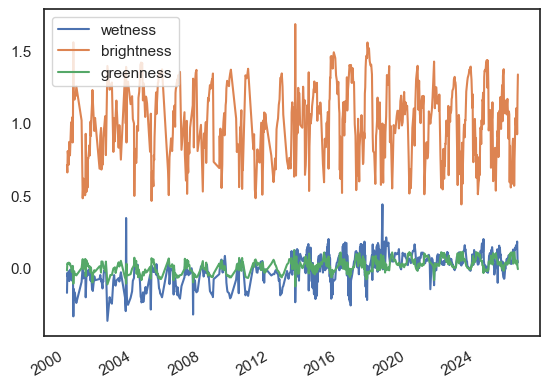

In [767]:
# COMPUTE TCT FOR ENTIRE LANDSAT COLLECTION
landsat_tct = compute_landsat_TCT(df=landsat_df).dropna()
#landsat_tct = slice_by_dates(landsat_tct, '2024', '2026')
landsat_tct[['wetness', 'brightness', 'greenness']].plot()

<Axes: >

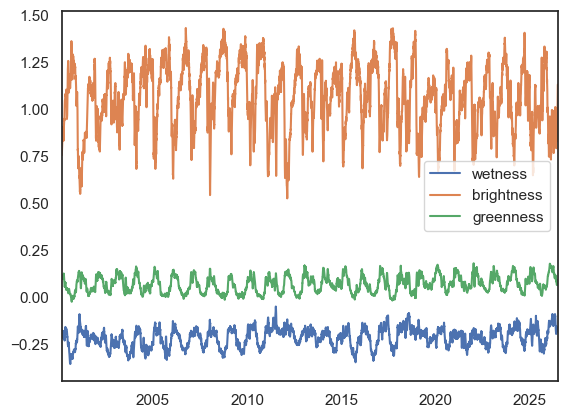

In [768]:
# COMPUTE TCT FOR ENTIRE MODIS COLLECTION
modis_tct = compute_modis_TCT(df=modis_df)
#modis_tct = slice_by_dates(modis_tct, '2024', '2026')
modis_tct[['wetness', 'brightness', 'greenness']].plot()

##### FUSION DE SENSORES EN DIFERENTES COMBINACIONES
Fusionar valores TCT "crudos" no da buenos resultados porque los resultados absolutos de TM y OLI no son equivalentes (estandarizados sí)
- Landsat TM - MODIS
- Landsat OLI - MODIS
- Landsat TM/OLI estandarizados por separado - MODIS estandarizado

In [769]:
# DIFFERENTIATE BETWEEN LANDSAT SENSORS (TM/OLI)
landsatTM_tct = landsat_tct[landsat_tct['Spacecraft'].isin(['LANDSAT_5', 'LANDSAT_7'])]
landsatOLI_tct = landsat_tct[landsat_tct['Spacecraft'].isin(['LANDSAT_8', 'LANDSAT_9'])]

In [770]:
# landsatTM_tct 2000-02-03 - 2018-12-21
# landsatOLI_tct 2013-03-23 - 2026-06-26

In [771]:
# FILTRADO DE COLUMNAS PREVIO A LA FUSION
tct_cols = ['brightness', 'greenness', 'wetness']

modis_tct = filter_columns(modis_tct, tct_cols)
landsatTM_tct = filter_columns(landsatTM_tct, tct_cols)
landsatOLI_tct = filter_columns(landsatOLI_tct, tct_cols)

In [772]:
# ESTANDARIZA SERIES TM Y OLI POR SEPARADO, LUEGO SE RE-UNEN
landsatTM_tct_z = landsatTM_tct.apply(zscore, nan_policy='omit')
landsatOLI_tct_z = landsatOLI_tct.apply(zscore, nan_policy='omit')
landsatTMOLI_tct_z = pd.concat([landsatTM_tct_z, landsatOLI_tct_z]).sort_index()

# ESTANDARIZA SERIE MODIS
modis_tct_z = modis_tct.apply(zscore, nan_policy='omit')


In [773]:
# FUSION LANDSAT TM - MODIS
sensor_fusion_results_TM = fuse_sensors(
    modis_df=modis_tct,
    landsat_df=landsatTM_tct,
    band_mapping=band_mapping,
    test_size=0.3,
    sigma_threshold=3.0,
    verbose_summary=False,
    verbose_plots=False
)


Processing brightness (348 coincident points)
Train - R2: 0.722 | MAE: 0.088 | RMSE: 0.128
Test  - R2: 0.729  | MAE: 0.083  | RMSE: 0.133

Processing greenness (348 coincident points)
Train - R2: 0.673 | MAE: 0.016 | RMSE: 0.023
Test  - R2: 0.622  | MAE: 0.018  | RMSE: 0.027

Processing wetness (348 coincident points)
Train - R2: 0.529 | MAE: 0.04 | RMSE: 0.063
Test  - R2: 0.677  | MAE: 0.038  | RMSE: 0.049


In [774]:
# metrics_df_TM = format_metrics_table(sensor_fusion_results_TM['metrics'])
# print(metrics_df_TM.to_string())

In [775]:
# FUSION LANDSAT OLI - MODIS
sensor_fusion_results_OLI = fuse_sensors(
    modis_df=modis_tct,
    landsat_df=landsatOLI_tct,
    band_mapping=band_mapping,
    test_size=0.3,
    sigma_threshold=3.0,
    verbose_summary=False,
    verbose_plots=False
)


Processing brightness (377 coincident points)
Train - R2: 0.694 | MAE: 0.101 | RMSE: 0.136
Test  - R2: 0.667  | MAE: 0.104  | RMSE: 0.137

Processing greenness (377 coincident points)
Train - R2: 0.801 | MAE: 0.012 | RMSE: 0.016
Test  - R2: 0.667  | MAE: 0.014  | RMSE: 0.021

Processing wetness (377 coincident points)
Train - R2: 0.48 | MAE: 0.034 | RMSE: 0.047
Test  - R2: 0.315  | MAE: 0.038  | RMSE: 0.052


In [776]:
# metrics_df_OLI = format_metrics_table(sensor_fusion_results_OLI['metrics'])
# print(metrics_df_OLI.to_string())

In [777]:
# FUSION LANDSAT TM/OLI Z - MODIS
sensor_fusion_results_TM_OLI_Z = fuse_sensors(
    modis_df=modis_tct_z,
    landsat_df=landsatTMOLI_tct_z,
    band_mapping=band_mapping,
    test_size=0.3,
    sigma_threshold=3.0,
    verbose_summary=False,
    verbose_plots=False
)


Processing brightness (725 coincident points)
Train - R2: 0.705 | MAE: 0.387 | RMSE: 0.544
Test  - R2: 0.694  | MAE: 0.398  | RMSE: 0.548

Processing greenness (725 coincident points)
Train - R2: 0.696 | MAE: 0.373 | RMSE: 0.553
Test  - R2: 0.73  | MAE: 0.377  | RMSE: 0.517

Processing wetness (725 coincident points)
Train - R2: 0.479 | MAE: 0.51 | RMSE: 0.734
Test  - R2: 0.548  | MAE: 0.473  | RMSE: 0.647


In [778]:
# metrics_df_TM_OLI_Z = format_metrics_table(sensor_fusion_results_TM_OLI_Z['metrics'])
# print(metrics_df_TM_OLI_Z.to_string())

##### EVALUACION DE DIFERENCIAS ENTRE SERIES TCT TM, OLI Y MODIS (2013-2018)

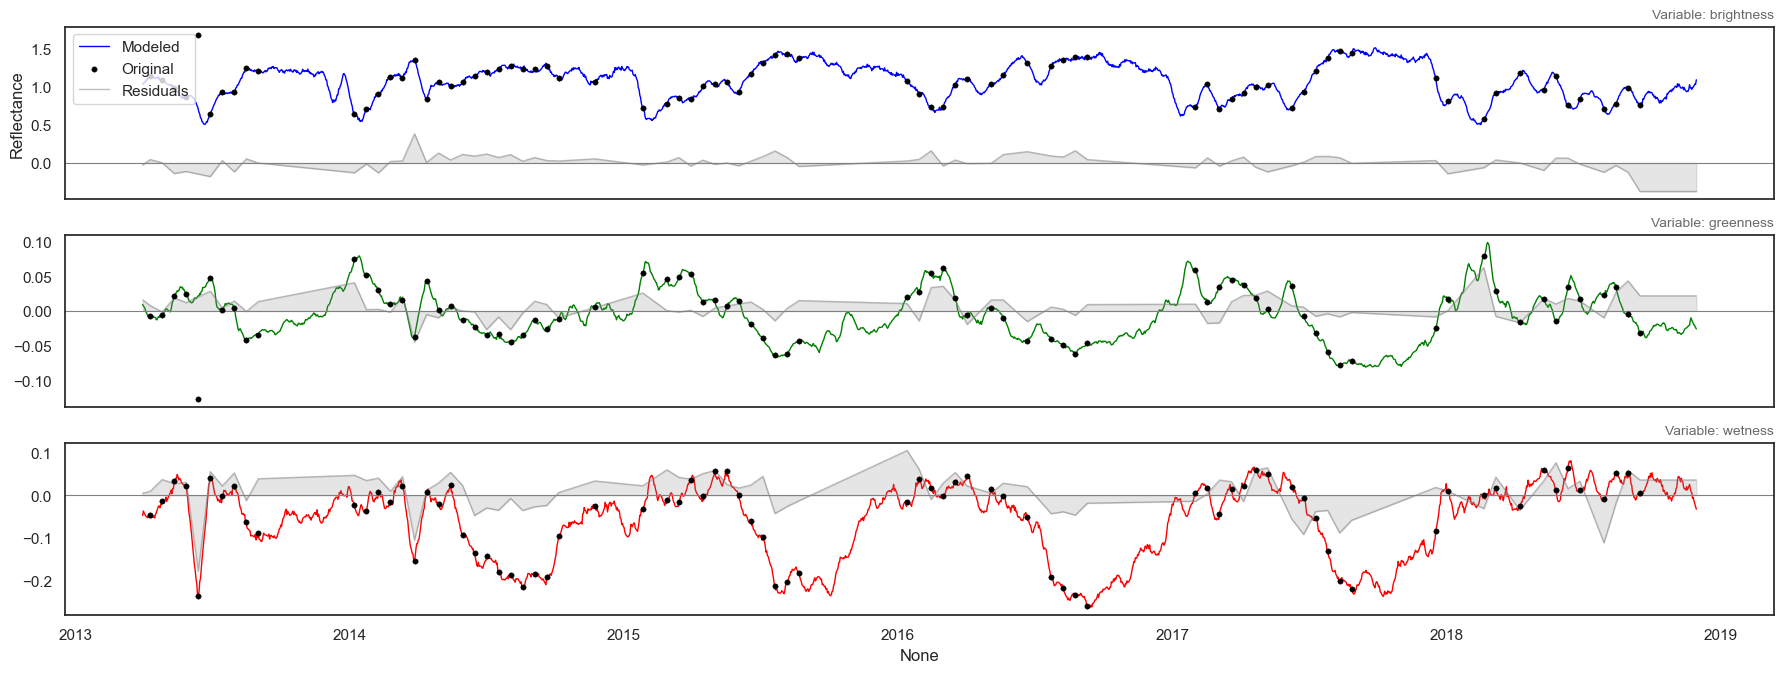

In [779]:
plot_observed_modeled_timeseries(
    predicted_df=sensor_fusion_results_TM['anchored'],
    original_df=landsatTM_tct,
    residuals_df=sensor_fusion_results_TM['residuals_interpolated'],
    start='2013-04',
    end='2018-11'
)

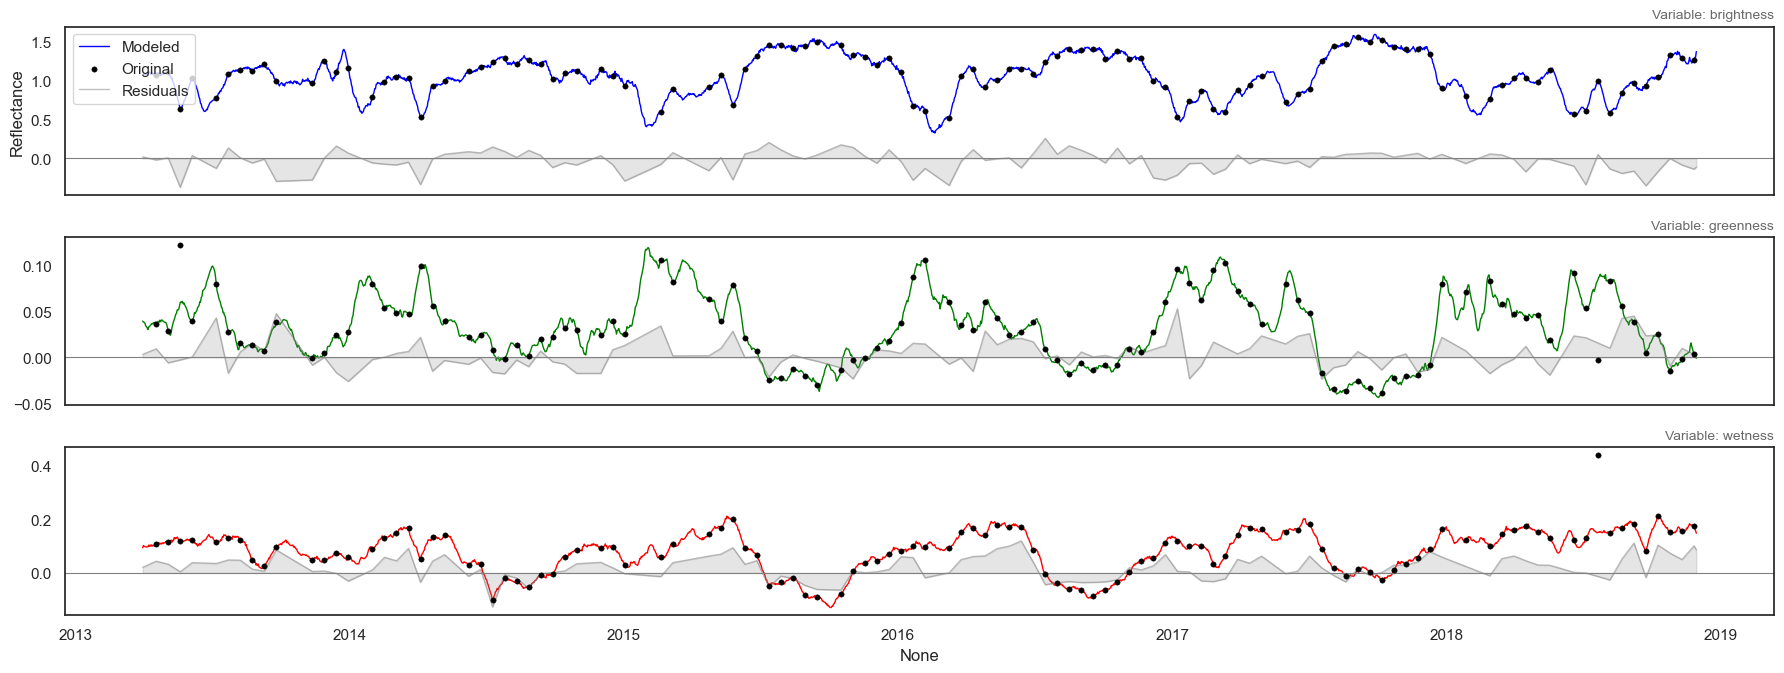

In [780]:
plot_observed_modeled_timeseries(
    predicted_df=sensor_fusion_results_OLI['anchored'],
    original_df=landsatOLI_tct,
    residuals_df=sensor_fusion_results_OLI['residuals_interpolated'],
    start='2013-04',
    end='2018-11'
)

In [781]:
# PREPARACION DE DATOS PARA GRAFICOS SIGUIENTES

# Clipeo a fechas comunes
start_shared = '2013-04'
end_shared = '2018-11'
landsatTM_tct_clipped = slice_by_dates(landsatTM_tct, start_shared, end_shared)
landsatOLI_tct_clipped = slice_by_dates(landsatOLI_tct, start_shared, end_shared)
modis_tct_clipped = slice_by_dates(modis_tct, start_shared, end_shared)

# Estandarizacion
landsatTM_tct_clipped_z = landsatTM_tct_clipped.apply(zscore, nan_policy='omit')
landsatOLI_tct_clipped_z = landsatOLI_tct_clipped.apply(zscore, nan_policy='omit')
modis_tct_clipped_z = modis_tct_clipped.apply(zscore, nan_policy='omit')

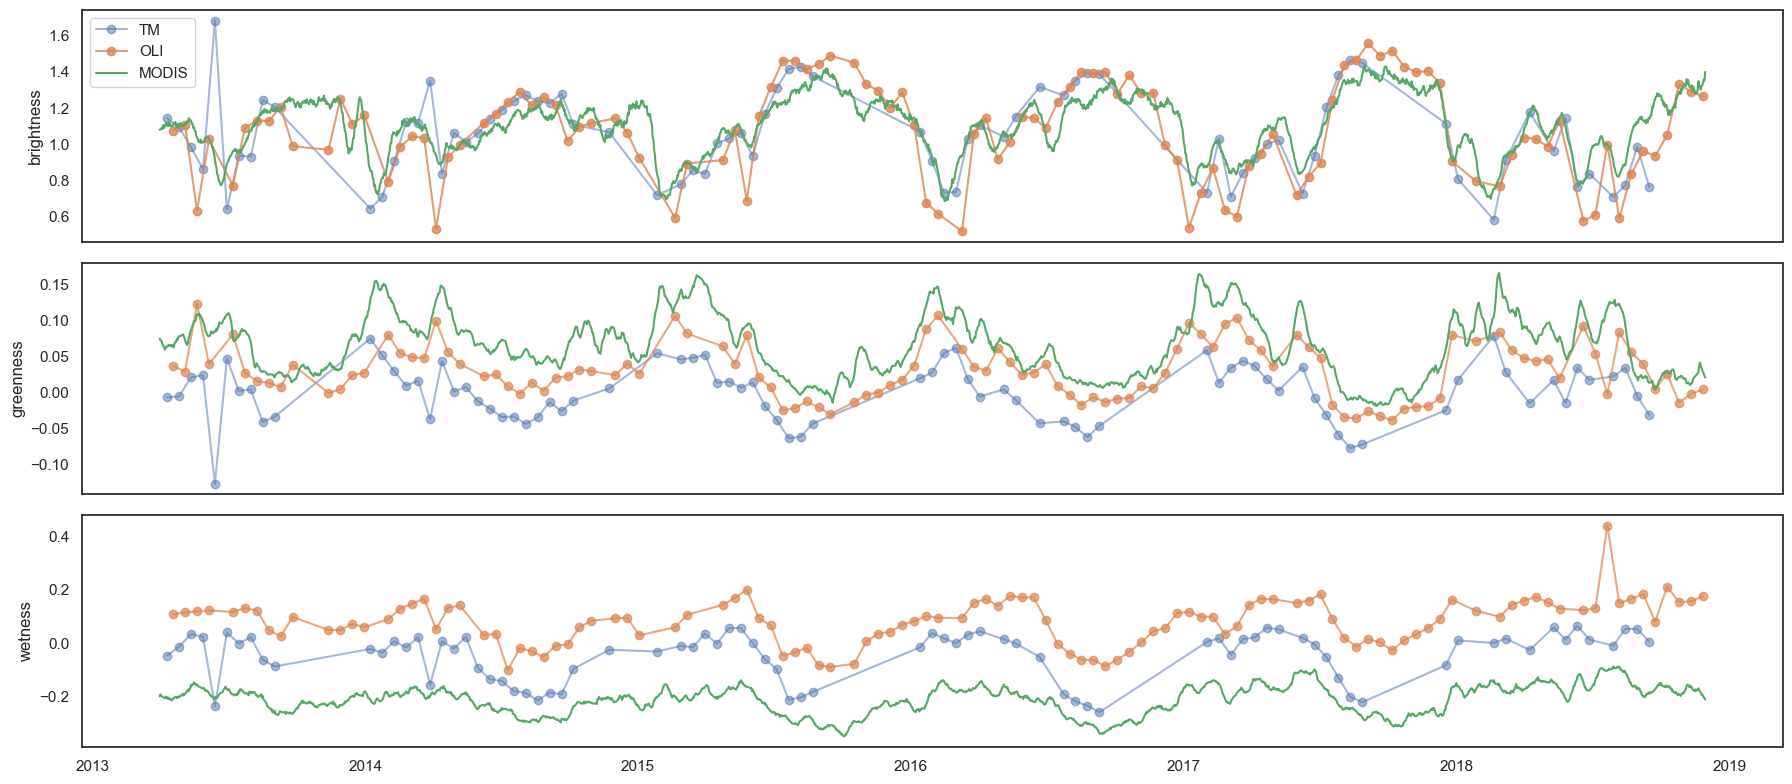

In [782]:
# COMPARACION DE TCT TM VS OLI ORIGINALES SIN ESTANDARIZAR
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

ax1.plot(landsatTM_tct_clipped.index, landsatTM_tct_clipped['brightness'], 
         label='TM', marker='o', markersize=6, alpha=0.5)
ax1.plot(landsatOLI_tct_clipped.index, landsatOLI_tct_clipped['brightness'], 
         label='OLI', marker='o', markersize=6, alpha=0.8)
ax1.plot(modis_tct_clipped.index, modis_tct_clipped['brightness'], label='MODIS')

ax1.set_ylabel('brightness')
ax1.legend(loc='upper left')

ax2.plot(landsatTM_tct_clipped.index, landsatTM_tct_clipped['greenness'],
         label='TM', marker='o', markersize=6, alpha=0.5)
ax2.plot(landsatOLI_tct_clipped.index, landsatOLI_tct_clipped['greenness'], 
         label='OLI', marker='o', markersize=6, alpha=0.7)
ax2.plot(modis_tct_clipped.index, modis_tct_clipped['greenness'], label='MODIS')
ax2.set_ylabel('greenness')

ax3.plot(landsatTM_tct_clipped.index, landsatTM_tct_clipped['wetness'],
         label='TM', marker='o', markersize=6, alpha=0.5)
ax3.plot(landsatOLI_tct_clipped.index, landsatOLI_tct_clipped['wetness'], 
         label='OLI', marker='o', markersize=6, alpha=0.7)
ax3.plot(modis_tct_clipped.index, modis_tct_clipped['wetness'], label='MODIS')
ax3.set_ylabel('wetness')

plt.tight_layout()
plt.show()

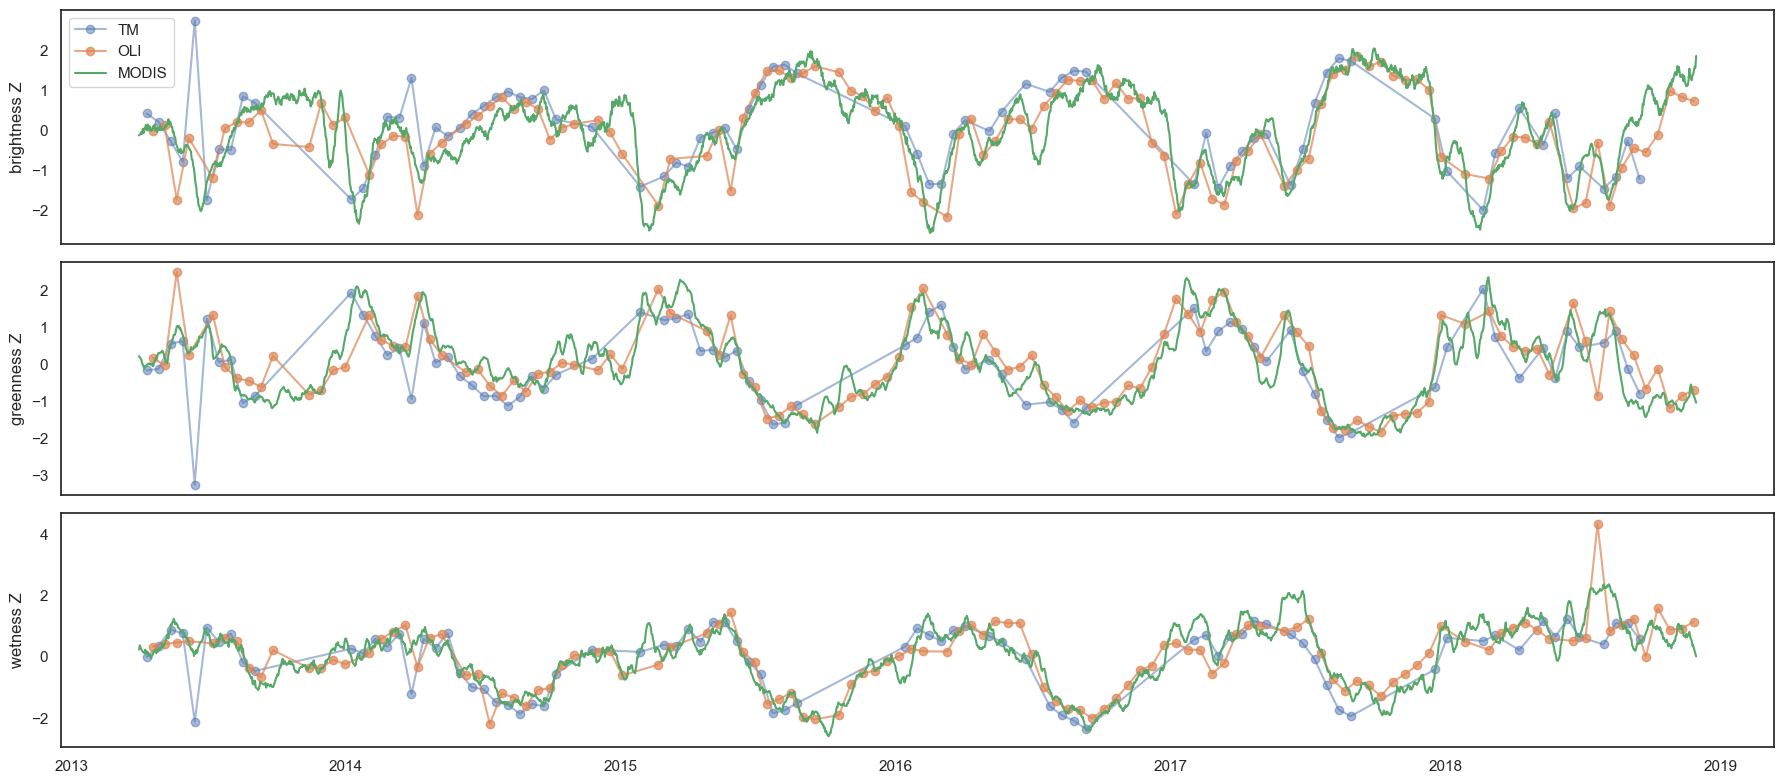

In [783]:
# COMPARACION DE TCT TM VS OLI ORIGINALES ESTANDARIZADOS
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

ax1.plot(landsatTM_tct_clipped.index, landsatTM_tct_clipped_z['brightness'], 
         label='TM', marker='o', markersize=6, alpha=0.5)
ax1.plot(landsatOLI_tct_clipped.index, landsatOLI_tct_clipped_z['brightness'], 
         label='OLI', marker='o', markersize=6, alpha=0.7)
ax1.plot(modis_tct_clipped.index, modis_tct_clipped_z['brightness'], label='MODIS')
ax1.set_ylabel('brightness Z')
ax1.legend(loc='upper left')

ax2.plot(landsatTM_tct_clipped.index, landsatTM_tct_clipped_z['greenness'],
         label='TM', marker='o', markersize=6, alpha=0.5)
ax2.plot(landsatOLI_tct_clipped.index, landsatOLI_tct_clipped_z['greenness'], 
         label='OLI', marker='o', markersize=6, alpha=0.7)
ax2.plot(modis_tct_clipped.index, modis_tct_clipped_z['greenness'], label='MODIS')
ax2.set_ylabel('greenness Z')

ax3.plot(landsatTM_tct_clipped.index, landsatTM_tct_clipped_z['wetness'],
         label='TM', marker='o', markersize=6, alpha=0.5)
ax3.plot(landsatOLI_tct_clipped.index, landsatOLI_tct_clipped_z['wetness'], 
         label='OLI', marker='o', markersize=6, alpha=0.7)
ax3.plot(modis_tct_clipped.index, modis_tct_clipped_z['wetness'], label='MODIS')
ax3.set_ylabel('wetness Z')

plt.tight_layout()
plt.show()

In [784]:
# PREPARACION DE DATOS PARA GRAFICOS SIGUIENTES

# Definicion de variables
TM_synthetic = sensor_fusion_results_TM['anchored']
OLI_synthetic = sensor_fusion_results_OLI['anchored']

# Clipeo a fechas comunes
TM_synthetic_clipped = slice_by_dates(TM_synthetic, start_shared, end_shared)
OLI_synthetic_clipped = slice_by_dates(OLI_synthetic, start_shared, end_shared)

# Estandarizacion
TM_synthetic_clipped_z = TM_synthetic_clipped.apply(zscore, nan_policy='omit')
OLI_synthetic_clipped_z = OLI_synthetic_clipped.apply(zscore, nan_policy='omit')

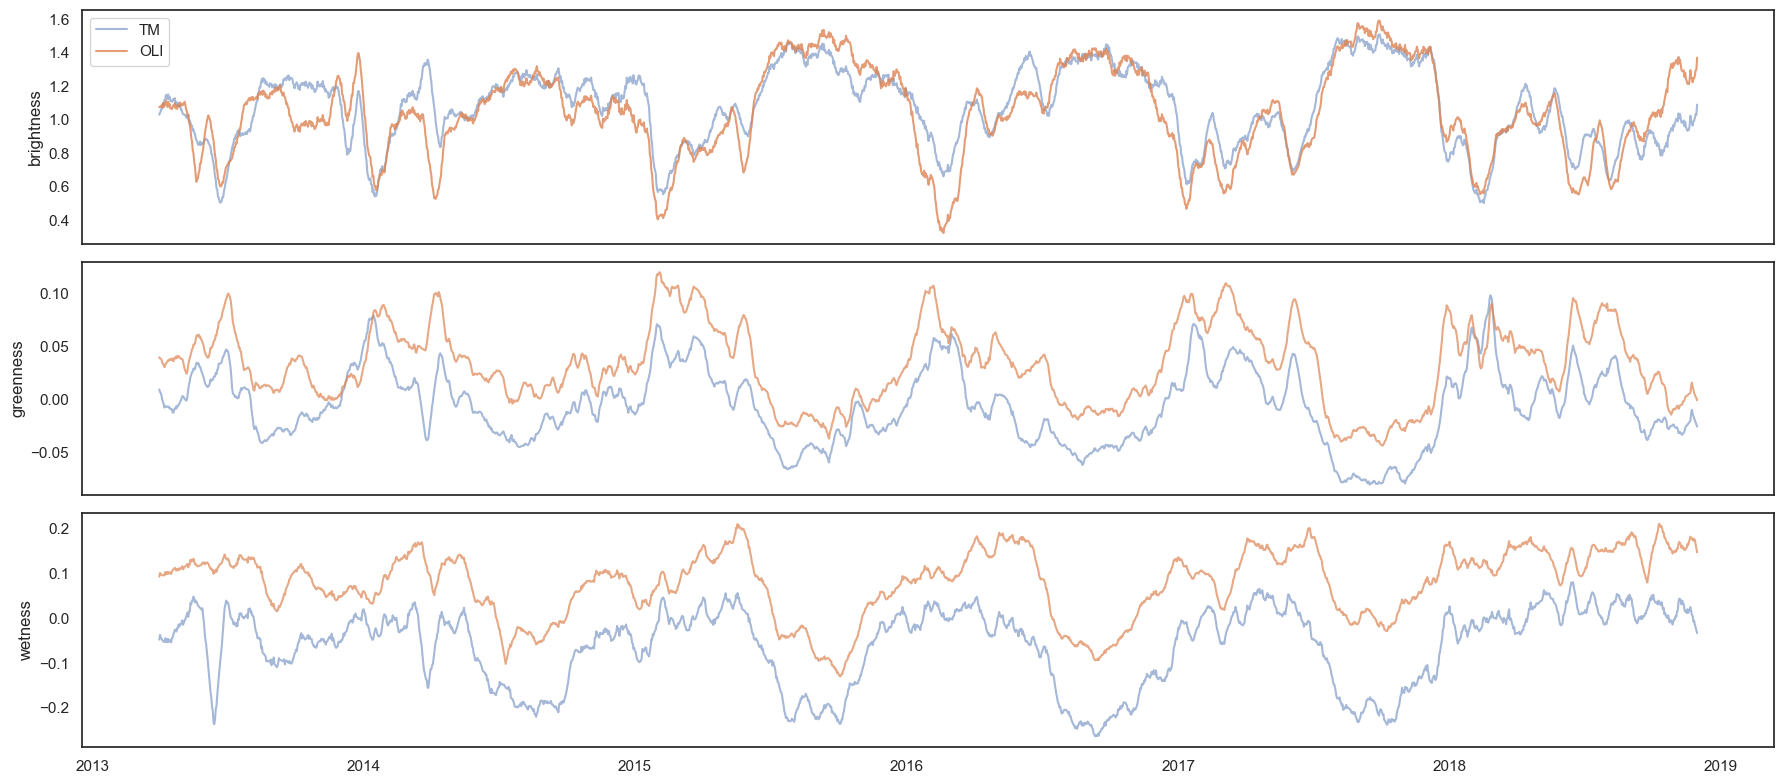

In [785]:
# COMPARACION DE TCT TM VS OLI SINTETICOS SIN ESTANDARIZAR
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

ax1.plot(TM_synthetic_clipped.index, TM_synthetic_clipped['brightness'], 
         label='TM', alpha=0.5)
ax1.plot(OLI_synthetic_clipped.index, OLI_synthetic_clipped['brightness'], 
         label='OLI', alpha=0.8)
ax1.set_ylabel('brightness')
ax1.legend(loc='upper left')

ax2.plot(TM_synthetic_clipped.index, TM_synthetic_clipped['greenness'],
         label='TM', alpha=0.5)
ax2.plot(OLI_synthetic_clipped.index, OLI_synthetic_clipped['greenness'], 
         label='OLI', alpha=0.7)
ax2.set_ylabel('greenness')

ax3.plot(TM_synthetic_clipped.index, TM_synthetic_clipped['wetness'],
         label='TM', alpha=0.5)
ax3.plot(OLI_synthetic_clipped.index, OLI_synthetic_clipped['wetness'], 
         label='OLI', alpha=0.7)
ax3.set_ylabel('wetness')

plt.tight_layout()
plt.show()

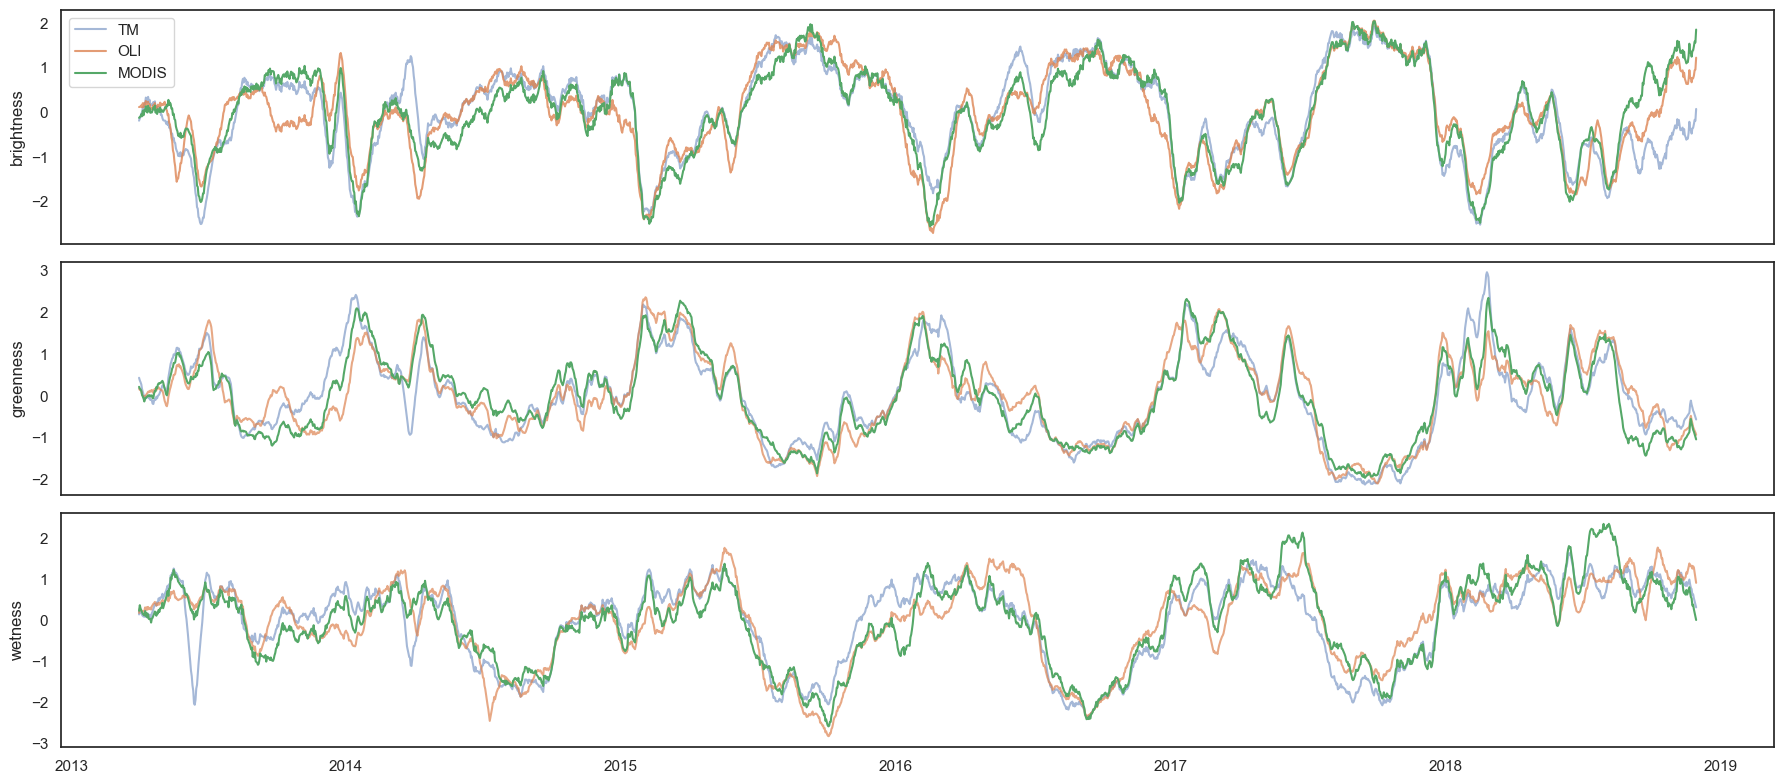

In [786]:
# COMPARACION DE TCT TM VS OLI SINTETICOS ESTANDARIZADOS
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

ax1.plot(TM_synthetic_clipped.index, TM_synthetic_clipped_z['brightness'], 
         label='TM', alpha=0.5)
ax1.plot(OLI_synthetic_clipped.index, OLI_synthetic_clipped_z['brightness'], 
         label='OLI', alpha=0.8)
ax1.plot(modis_tct_clipped.index, modis_tct_clipped_z['brightness'], label='MODIS')
ax1.set_ylabel('brightness')
ax1.legend(loc='upper left')

ax2.plot(TM_synthetic_clipped.index, TM_synthetic_clipped_z['greenness'],
         label='TM', alpha=0.5)
ax2.plot(OLI_synthetic_clipped.index, OLI_synthetic_clipped_z['greenness'], 
         label='OLI', alpha=0.7)
ax2.plot(modis_tct_clipped.index, modis_tct_clipped_z['greenness'], label='MODIS')
ax2.set_ylabel('greenness')

ax3.plot(TM_synthetic_clipped.index, TM_synthetic_clipped_z['wetness'],
         label='TM', alpha=0.5)
ax3.plot(OLI_synthetic_clipped.index, OLI_synthetic_clipped_z['wetness'], 
         label='OLI', alpha=0.7)
ax3.plot(modis_tct_clipped.index, modis_tct_clipped_z['wetness'], label='MODIS')
ax3.set_ylabel('wetness')

plt.tight_layout()
plt.show()

##### EVALUACION DE SERIE LANDSAT SINTETICA TM/OLI Z

In [787]:
# Definicion de variables
TM_OLI_synthetic = sensor_fusion_results_TM_OLI_Z['anchored']

Text(0, 0.5, 'wetness')

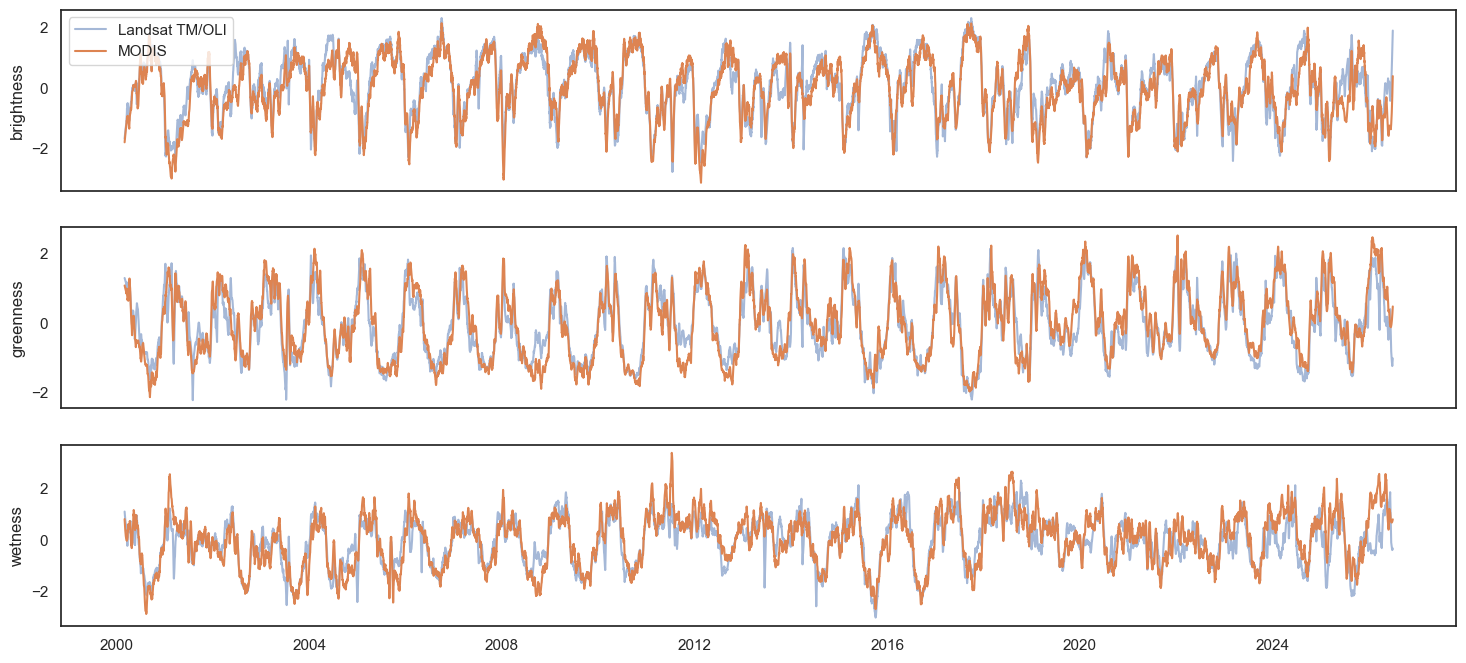

In [788]:
# COMPARACION DE TCT TM-OLI-Z VS MODIS 

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

ax1.plot(TM_OLI_synthetic.index, TM_OLI_synthetic['brightness'], 
         label='Landsat TM/OLI', alpha=0.5)
ax1.plot(modis_tct_z.index, modis_tct_z['brightness'], label='MODIS')
ax1.set_ylabel('brightness')
ax1.legend(loc='upper left')

ax2.plot(TM_OLI_synthetic.index, TM_OLI_synthetic['greenness'],
         label='Landsat TM/OLI', alpha=0.5)
ax2.plot(modis_tct_z.index, modis_tct_z['greenness'], label='MODIS')
ax2.set_ylabel('greenness')

ax3.plot(TM_OLI_synthetic.index, TM_OLI_synthetic['wetness'],
         label='Landsat TM/OLI', alpha=0.5)
ax3.plot(modis_tct_z.index, modis_tct_z['wetness'], label='MODIS')
ax3.set_ylabel('wetness')

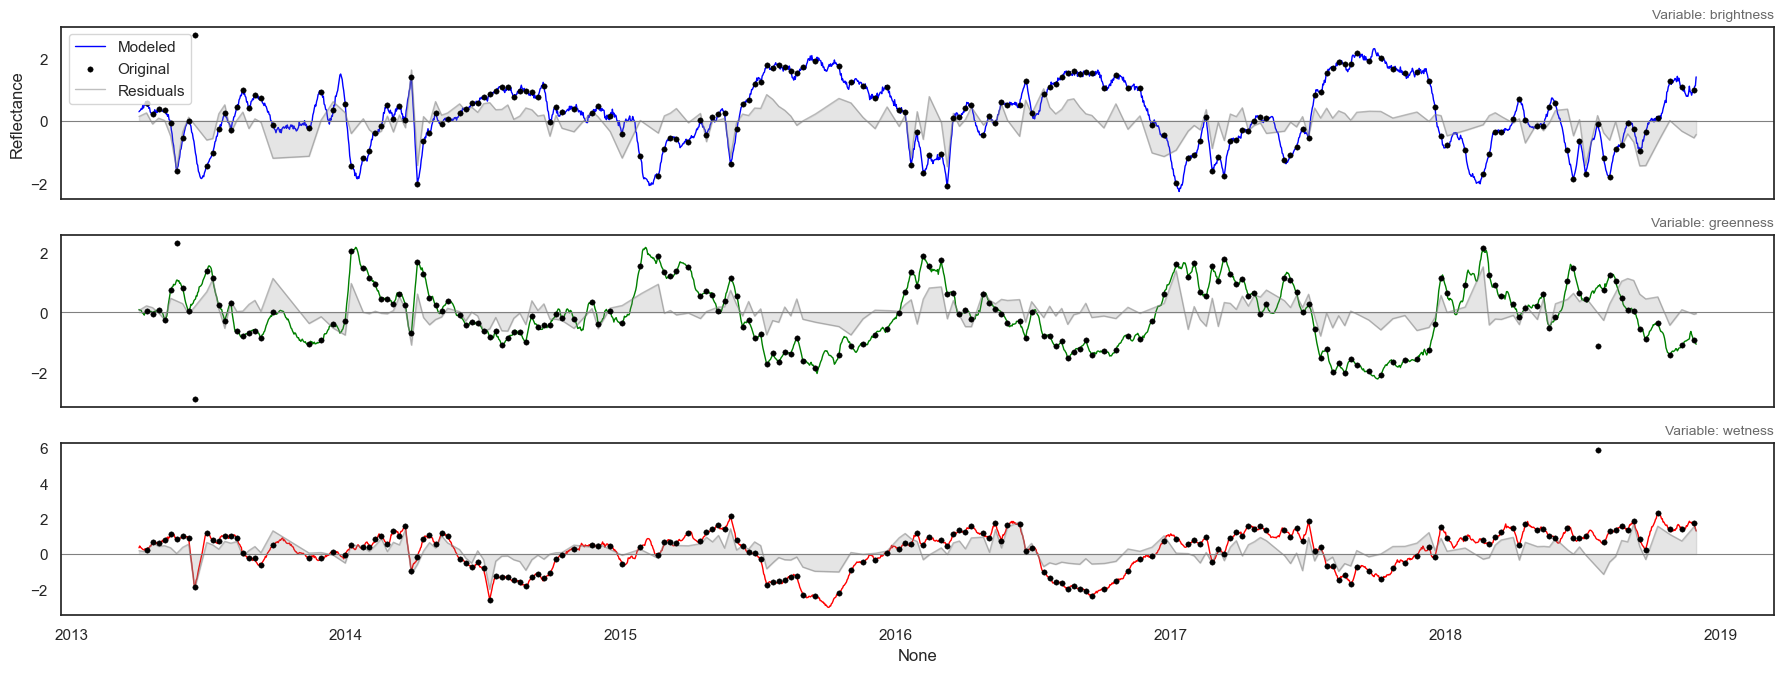

In [789]:
# LANDSAT TM/OLI Z SINTETICO ANCLADO (ESTANDARIZADO POR DEFECTO)
plot_observed_modeled_timeseries(
    predicted_df=sensor_fusion_results_TM_OLI_Z['anchored'],
    original_df=landsatTMOLI_tct_z,
    residuals_df=sensor_fusion_results_TM_OLI_Z['residuals_interpolated'],
    start='2013-04',
    end='2018-11'
)

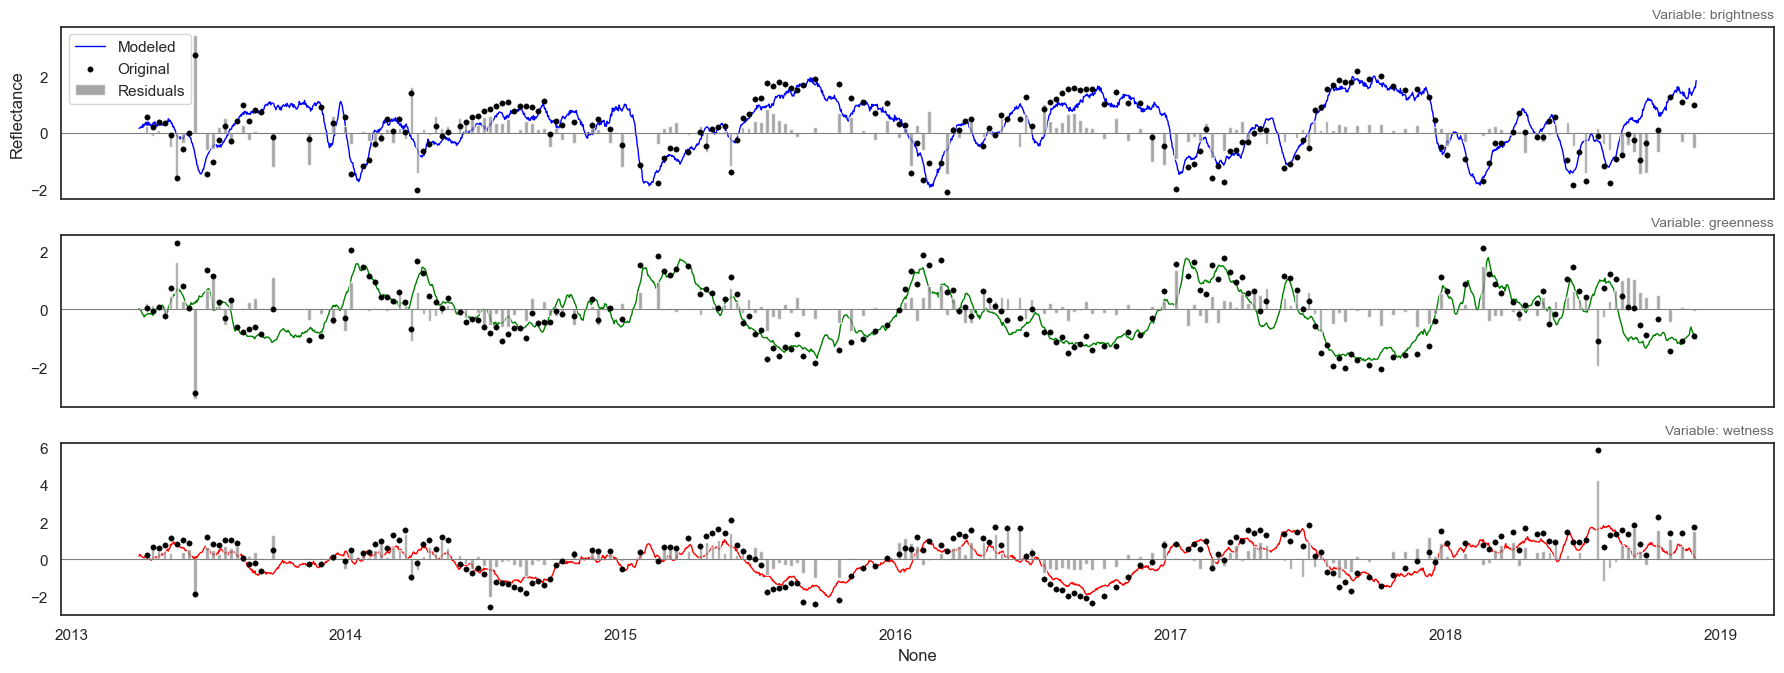

In [790]:
# LANDSAT TM/OLI Z SINTETICO (ESTANDARIZADO POR DEFECTO)
plot_observed_modeled_timeseries(
    predicted_df=sensor_fusion_results_TM_OLI_Z['predicted'],
    original_df=landsatTMOLI_tct_z,
    residuals_df=sensor_fusion_results_TM_OLI_Z['residuals'],
    start='2013-04',
    end='2018-11'
)

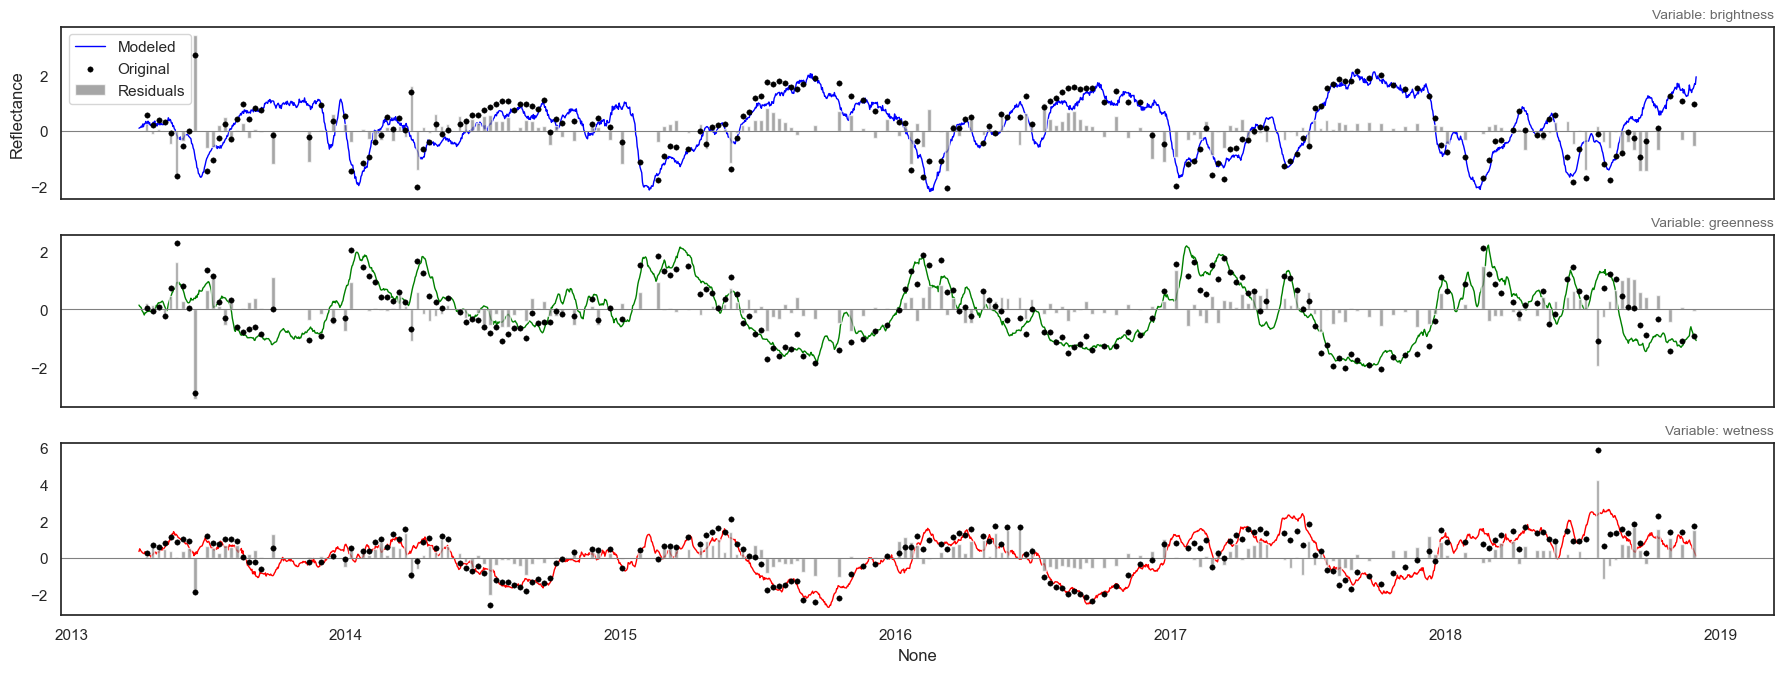

In [791]:
# MODIS SUAVIZADO ESTANDARIZADO
plot_observed_modeled_timeseries(
    predicted_df=modis_tct_z,
    original_df=landsatTMOLI_tct_z,
    residuals_df=sensor_fusion_results_TM_OLI_Z['residuals'],
    start='2013-04',
    end='2018-11'
)

##### PREDICCIONES CON RF

In [792]:
insitu_df = process_insitu(
    filepath=insitu_filepath,
    start_date='2024-05-24',
    end_date='2026-05-14',
    cols_to_keep=target,
    outlier_threshold=3.0
    )

PCA = True
time_series = 'anchored'
lags = 5
features = ['brightness','greenness', 'wetness']

if time_series == 'anchored':
    daily_time_series = sensor_fusion_results_TM_OLI_Z['anchored']
elif time_series == 'predicted':
    daily_time_series = sensor_fusion_results_TM_OLI_Z['predicted']
elif time_series == 'modis':
    daily_time_series = modis_tct_z

if PCA == True:
    pca_df = principal_component_analysis(daily_time_series, feature_columns=features, n_components=2, random_state=42)
    features = ['PC_1', 'PC_2']
    daily_time_series = pca_df


--- PCA Evaluation ---
Component 1 explains: 78.68% of the variance
Component 2 explains: 17.97% of the variance
Total information retained: 96.66%
----------------------
                PC_1      PC_2
brightness -0.609315  0.371531
greenness   0.612898 -0.339827
wetness     0.503082  0.863992


In [793]:
daily_time_series

,PC_1,PC_2
2000-03-01,2.629688,-0.017361
2000-03-02,2.551608,-0.063825
2000-03-03,2.476939,-0.106332
2000-03-04,2.405682,-0.144882
2000-03-05,2.337837,-0.179475
...,...,...
2026-06-26,-1.712545,0.576584
2026-06-27,-1.760932,0.623971
2026-06-28,-1.811075,0.675689
2026-06-29,-1.862975,0.731737


In [794]:
cc_df = merge_datasets(insitu_df, daily_time_series, how='inner')
cc_df2 = cross_correlations_analysis(cc_df, target_col=target, feature_cols=features, max_lag=10)
print(cc_df2)

   feature direction  lag_value    lag_name  correlation  abs_correlation
0     PC_1  same_day          0       lag_0     0.154867         0.154867
1     PC_1    future         -1   future_-1     0.119060         0.119060
2     PC_1      past          1      past_1     0.112478         0.112478
3     PC_1    future         -2   future_-2     0.109873         0.109873
4     PC_1    future         -5   future_-5     0.102776         0.102776
5     PC_1    future         -3   future_-3     0.099714         0.099714
6     PC_1      past         10     past_10    -0.092050         0.092050
7     PC_1      past          2      past_2     0.072404         0.072404
8     PC_1      past          9      past_9    -0.064899         0.064899
9     PC_1      past          8      past_8    -0.059653         0.059653
10    PC_1    future         -4   future_-4     0.056004         0.056004
11    PC_1      past          6      past_6    -0.049866         0.049866
12    PC_1    future         -8   futu

In [795]:
nLags = lags
intervalLags = 1
lags_list = list(range(1, nLags, intervalLags))

time_df = (
    daily_time_series
    .pipe(add_lags, features=features, past_lags=lags_list, future_lags=lags_list)
    .pipe(add_time)
)
training_df = merge_datasets(insitu_df, time_df, how='inner')


Chronological split applied at: 2025-05-18
Training samples: 360 | Testing samples: 361
{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 400}
Model performance (testing):
 {'RMSE': 0.1438, 'MAE': 0.1218, 'R2': 0.431, 'PBIAS': np.float64(38.0569), 'MSE': 0.0207}
Model performance (training):
 {'RMSE': 0.0145, 'MAE': 0.0092, 'R2': 0.9944, 'PBIAS': np.float64(-0.3839), 'MSE': 0.0002}


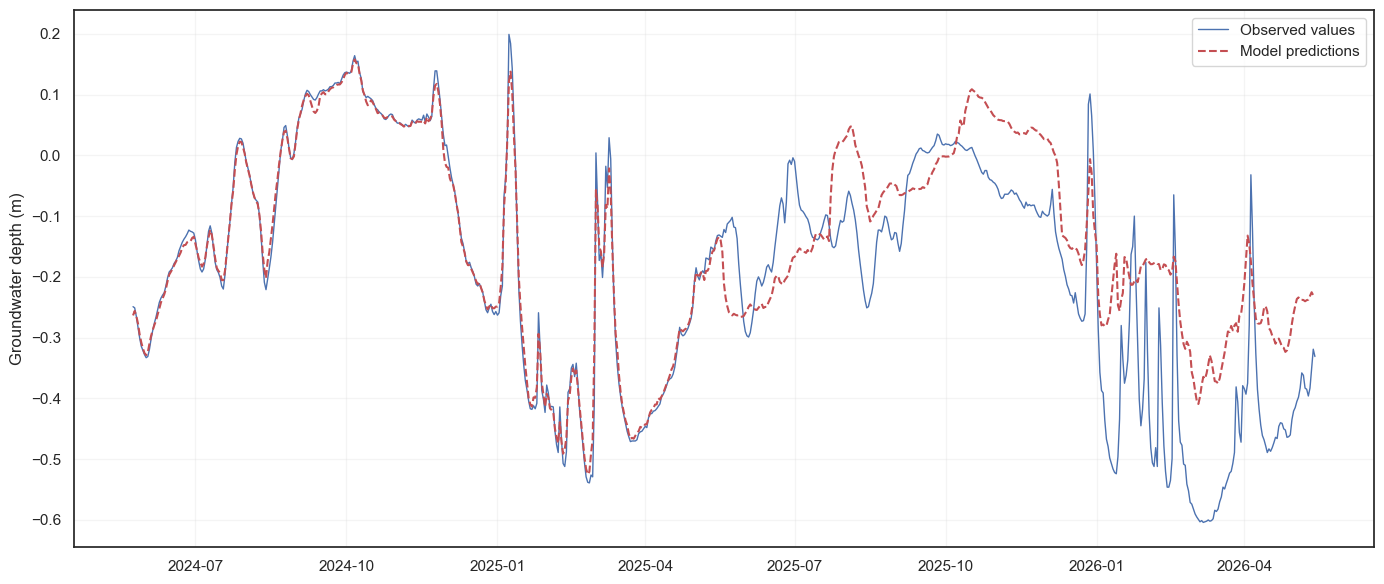

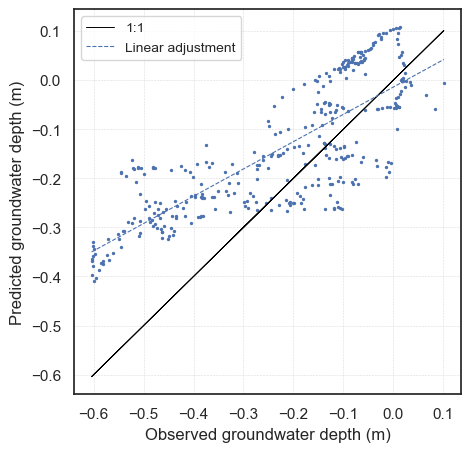

In [796]:
X_train_scaled, X_test_scaled, y_train, y_test, scaler, test_dates = preprocess_for_ML_chrono(
    df=training_df, 
    target=[target], 
    train_size=0.5
    )

best_params = tune_model(
    X_train_scaled=X_train_scaled, 
    y_train=y_train
    )

model = train_model(
    X_train_scaled=X_train_scaled, 
    y_train=y_train,
    best_params=best_params,
    random_state=42
    )

y_pred_test, y_pred_train, results_test, results_train = evaluate_model(
    model=model,
    X_test_scaled=X_test_scaled,
    y_test=y_test,
    X_train_scaled=X_train_scaled,
    y_train=y_train
    )

applied = apply_model(
    df=training_df,
    target=[target],
    scaler=scaler,
    model=model
    )

plot_timeseries_results(df=applied)
plot_pred_vs_real(y_test=y_test, y_pred=y_pred_test)